In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

import warnings

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [3]:
def load_evidence(fn, ds_name, metrics=False):
    # we only want derived since we're going to compare gene ids
    j = pd.read_json(fn)

    derived = j["derived"].apply(pd.Series).add_prefix("derived_")
    extracted = j["extracted"].apply(pd.Series).add_prefix("extracted_")
    source = j["source"].apply(pd.Series)#.add_prefix("source_")

    df = pd.concat([derived, extracted, source], axis=1)
    df["ds_name"] = ds_name

    if metrics:
        source_metrics = source["source_metrics"].apply(pd.Series).add_prefix("source_metrics_")
        source = pd.concat([source, source_metrics], axis=1)
    # drop the original columns


    # normalize the string values for cell types
    df["extracted_cell_type_label"] = df["extracted_cell_type_label"].str.strip().str.upper()
    # df["extracted_cell_type_id"] = df["extracted_cell_type_id"].str.strip().str.upper()

    df["derived_cell_type_label"] = df["derived_cell_type_label"].str.strip().str.upper()
    df["derived_cell_type_id"] = df["derived_cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    df["extracted_feature_name"] = df["extracted_feature_name"].str.strip().str.upper()
    df["derived_feature_name"] = df["derived_feature_name"].str.strip().str.upper()

    # df["extracted_feature_identifier"] = df["extracted_feature_identifier"].str.strip().str.upper()
    df["derived_feature_identifier"] = df["derived_feature_identifier"].str.strip().str.upper()


    return df

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [ ]:
# adipose_Hildreth2021
# adipose_Vijay2019
# adipose_Emont2022
# adipose Vijay2019

ds1 = "adipose_Emont2022"
ds2 = "adipose_Hildreth2021"

fn_hmn1   = f"../../data/{ds1}/evidence_human/evidence.json"
fn_deg1   = f"../../data/{ds1}/evidence_deg/evidence_unfiltered.json"

fn_hmn2   = f"../../data/{ds2}/evidence_human/evidence.json"
fn_deg2   = f"../../data/{ds2}/evidence_deg/evidence_unfiltered.json"

hmn1 = load_evidence(fn_hmn1, ds1)
hmn1 = hmn1.loc[:, hmn1.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"])
img1 = hmn1.query("source_type == 'image'")
txt1 = hmn1.query("source_type == 'text'")

deg1 = load_evidence(fn_deg1, ds1, metrics=False)
deg1 = deg1.loc[:, deg1.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"])

data1 = {
    "deg": deg1,
    "img": img1,
    "txt": txt1,
}

hmn2 = load_evidence(fn_hmn2, ds1)
hmn2 = hmn2.loc[:, hmn2.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"])
img2 = hmn2.query("source_type == 'image'")
txt2 = hmn2.query("source_type == 'text'")
deg2 = load_evidence(fn_deg2, ds2, metrics=False)
deg2 = deg2.loc[:, deg2.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"])

data2 = {
    "deg": deg2,
    "img": img2,
    "txt": txt2,
}

In [21]:
data1 = {
    "DEG": deg1,
    "IMG": img1,
    "TXT": txt1,
}

data2 = {
    "DEG": deg2,
    "IMG": img2,
    "TXT": txt2,
}

In [7]:
from functools import reduce 

celltypes = reduce(np.union1d, [
    hmn1["cell_type_id"].unique(),
    hmn2["cell_type_id"].unique(),
    deg1["cell_type_id"].unique(),
    deg2["cell_type_id"].unique()
])

In [76]:
import matplotlib.patches as patches


def hatch_cell(ax, i, j, hatch='//', color='white'):
    rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             linewidth=0, edgecolor='lightgrey', facecolor=color,
                             hatch=hatch, zorder=2, alpha=0.8)
    ax.add_patch(rect)



In [72]:
cjac = {       
        ('DEG', 'DEG'): lambda x: x[:,1] / (x[:,0] + x[:,1] + x[:,2]), # jaccard
        ('DEG', 'IMG'): lambda x: x[:,1] /          (x[:,1] + x[:,2]), # frac. of IMG genes in DEG
        ('DEG', 'TXT'): lambda x: x[:,1] /          (x[:,1] + x[:,2]), # frac. of TXT genes in DEG
        ('IMG', 'DEG'): lambda x: x[:,1] / (x[:,0] + x[:,1]),          # frac. of IMG genes in DEG
        ('IMG', 'IMG'): lambda x: x[:,1] / (x[:,0] + x[:,1] + x[:,2]), # jaccard
        ('IMG', 'TXT'): lambda x: x[:,1] /          (x[:,1] + x[:,2]), # frac. of TXT genes in IMG
        ('TXT', 'DEG'): lambda x: x[:,1] / (x[:,0] + x[:,1]),          # frac. of TXT genes in DEG
        ('TXT', 'IMG'): lambda x: x[:,1] / (x[:,0] + x[:,1]),          # frac. of TXT genes in IMG
        ('TXT', 'TXT'): lambda x: x[:,1] / (x[:,0] + x[:,1] + x[:,2])  # jaccard
}

cjac_label = {
        ('DEG', 'DEG'): "Jaccard Similarity",
        ('DEG', 'IMG'): "Frac. genes in DEG",
        ('DEG', 'TXT'): "Frac. genes in DEG",
        ('IMG', 'DEG'): "Frac. genes in IMG",
        ('IMG', 'IMG'): "Jaccard Similarity",
        ('IMG', 'TXT'): "Frac. genes in IMG",
        ('TXT', 'DEG'): "Frac. genes in DEG",
        ('TXT', 'IMG'): "Frac. genes in IMG",
        ('TXT', 'TXT'): "Jaccard Similarity"
}

In [111]:
def color_ax(ax):
    # Highlight the (1,1) outer grid cell
    # Add a dummy Axes that spans that slot and draw a Rectangle behind
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('none')  # Transparent so the rectangle is visible
    ax.spines[:].set_visible(False)  # Hide borders

    from matplotlib.patches import Rectangle

    # Add rectangle patch to that Axes
    ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                    color='lightgrey', zorder=-1))

    # Optional: Hide this dummy Axes so it doesn't obscure your actual subplots
    ax.set_zorder(-10)
    return ax

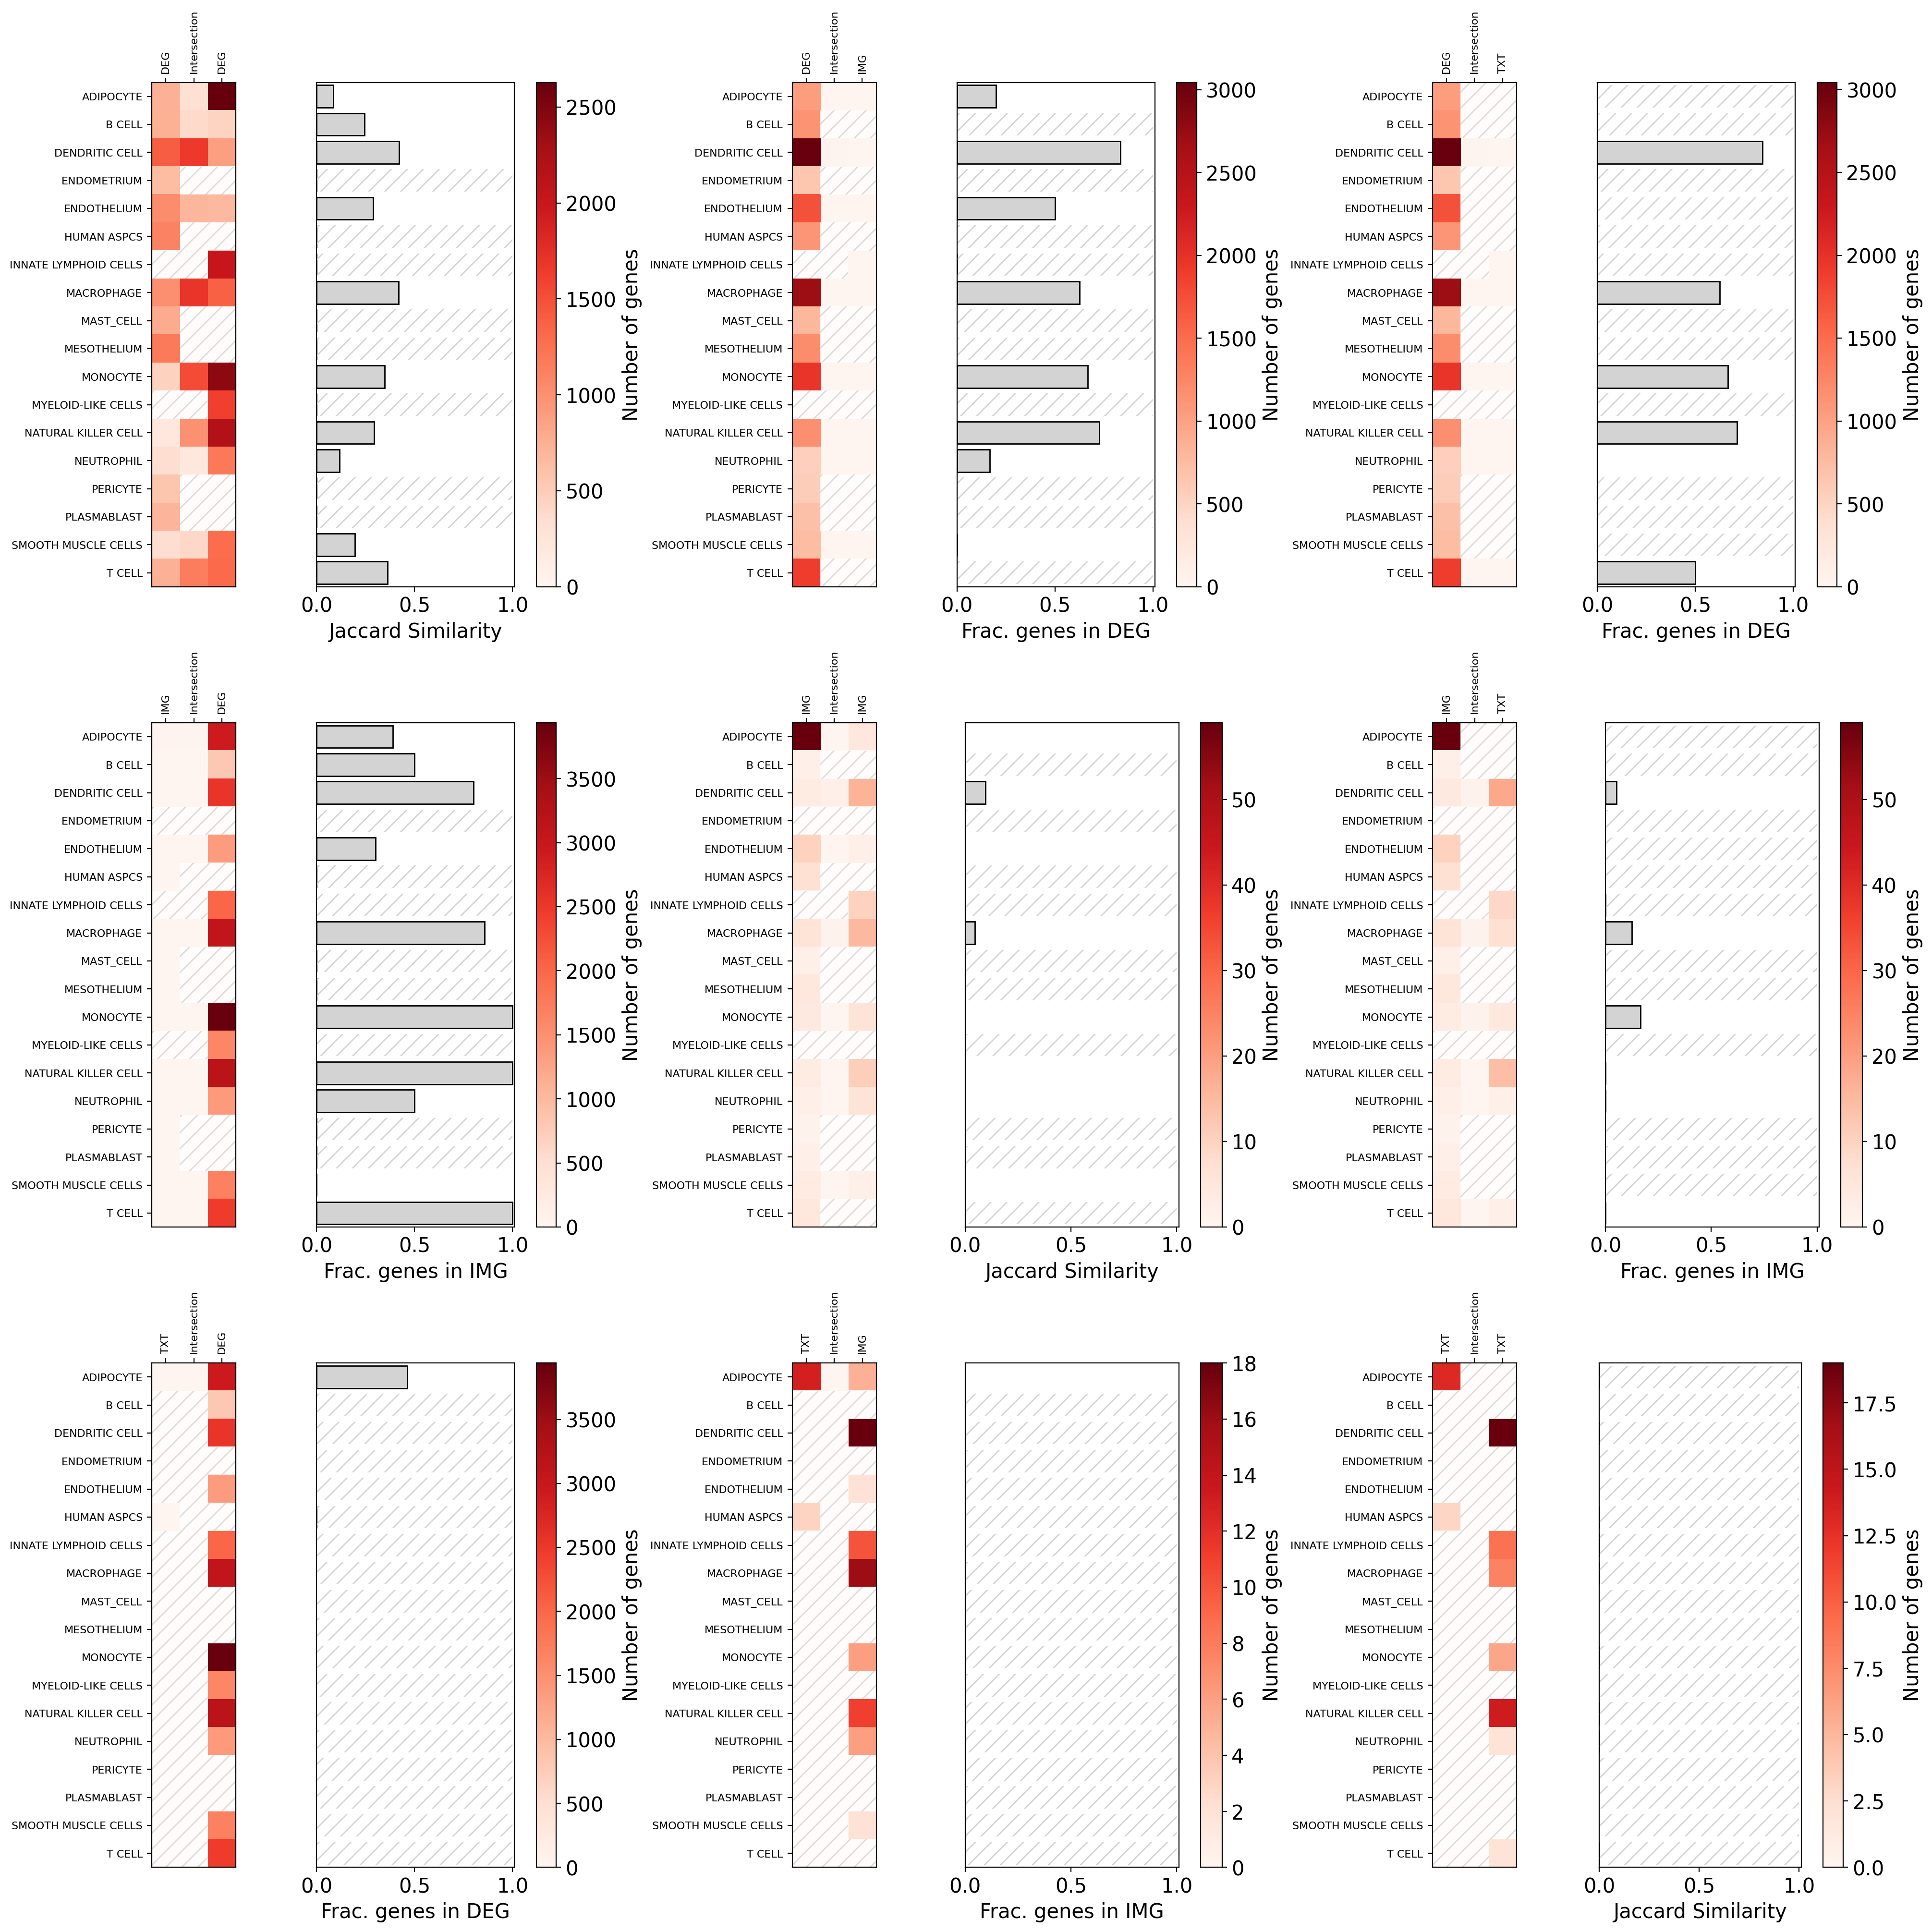

In [119]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

def compare_features(df1, df2, celltypes, label1, label2):
    t1 = df1.groupby("cell_type_id")["feature_identifier"].apply(list).reindex(celltypes, fill_value=[])
    t2 = df2.groupby("cell_type_id")["feature_identifier"].apply(list).reindex(celltypes, fill_value=[])

    l = t1.combine(t2, lambda a, b: np.setdiff1d(a, b).shape[0]).rename(label1)
    x = t1.combine(t2, lambda a, b: np.intersect1d(a, b).shape[0]).rename("x")
    r = t1.combine(t2, lambda a, b: np.setdiff1d(b, a).shape[0]).rename(label2)
    mtx = pd.concat([l, x, r], axis=1)
    nt1 = np.where(t1.apply(lambda x: len(x)) == 0)[0]
    nt2 = np.where(t2.apply(lambda x: len(x)) == 0)[0]
    return (mtx.values, nt1, nt2)

# Main plotting code
fig = plt.figure(figsize=(20, 20), constrained_layout=True)
og = fig.add_gridspec(3, 3)

axes = []
for a in range(3):
    for b in range(3):
        ig = og[a, b].subgridspec(1, 3, width_ratios=[10, 10, 1], wspace=0.0)
        axl = fig.add_subplot(ig[0])
        axr = fig.add_subplot(ig[1])
        cax = fig.add_subplot(ig[2])
        axes.append((axl, axr, cax))
        # color_ax(fig.add_subplot(og[a, b]))



combos = [
        ('DEG', 'DEG'),
        ('DEG', 'IMG'),
        ('DEG', 'TXT'),
        ('IMG', 'DEG'),
        ('IMG', 'IMG'),
        ('IMG', 'TXT'),
        ('TXT', 'DEG'),
        ('TXT', 'IMG'),
        ('TXT', 'TXT')
    ]

for idx, ((lab1, lab2), axs) in enumerate(zip(combos, axes)):
    axl, axr, cax = axs
    row = idx // 3
    col = idx % 3
    
    mtx, nt1, nt2 = compare_features(data1[lab1], data2[lab2], celltypes, lab1, lab2)

    xlabels = [f"{lab1}", "Intersection", f"{lab2}"]


    im = axl.imshow(mtx, cmap="Reds")
    fig.colorbar(im, cax=cax, label="Number of genes")


    # Apply hatch to specific cells
    for i in nt1:
        hatch_cell(axl, i, 0)
    for i in nt2:
        hatch_cell(axl, i, 2)
    for i in np.unique(np.concatenate([nt1, nt2])):
        hatch_cell(axl, i, 1)


    axl.set(**{
        "xticks": np.arange(len(xlabels)),
        "xticklabels": xlabels,
        "yticks": np.arange(len(celltypes)),
        "yticklabels": celltypes,
    })

    axl.set_xticklabels(axl.get_xticklabels(), rotation=90, fontsize=8)
    axl.set_yticklabels(axl.get_yticklabels(), fontsize=8)
    axl.xaxis.tick_top()

    xlabel = cjac_label[(lab1, lab2)]
    jac = cjac[(lab1, lab2)](mtx)
    
    axr.barh(np.arange(len(celltypes)), jac[::-1], edgecolor="black", facecolor="lightgrey")
    highlight_indices = np.unique(np.concatenate([nt1, nt2]))

    # Overlay bars with hatch patterns for highlighted indices
    for i in highlight_indices:
        axr.barh(len(celltypes)-i-1, 1, edgecolor="lightgrey",
                facecolor="none", hatch='//', linewidth=0)

    axr.set(**{
        "yticks": [],
        "xlim": (0, 1.01),
        "xlabel": xlabel,
        "ylim": (-0.5, len(celltypes)-0.5),
    })


fig.savefig("figures/inter_cmp.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

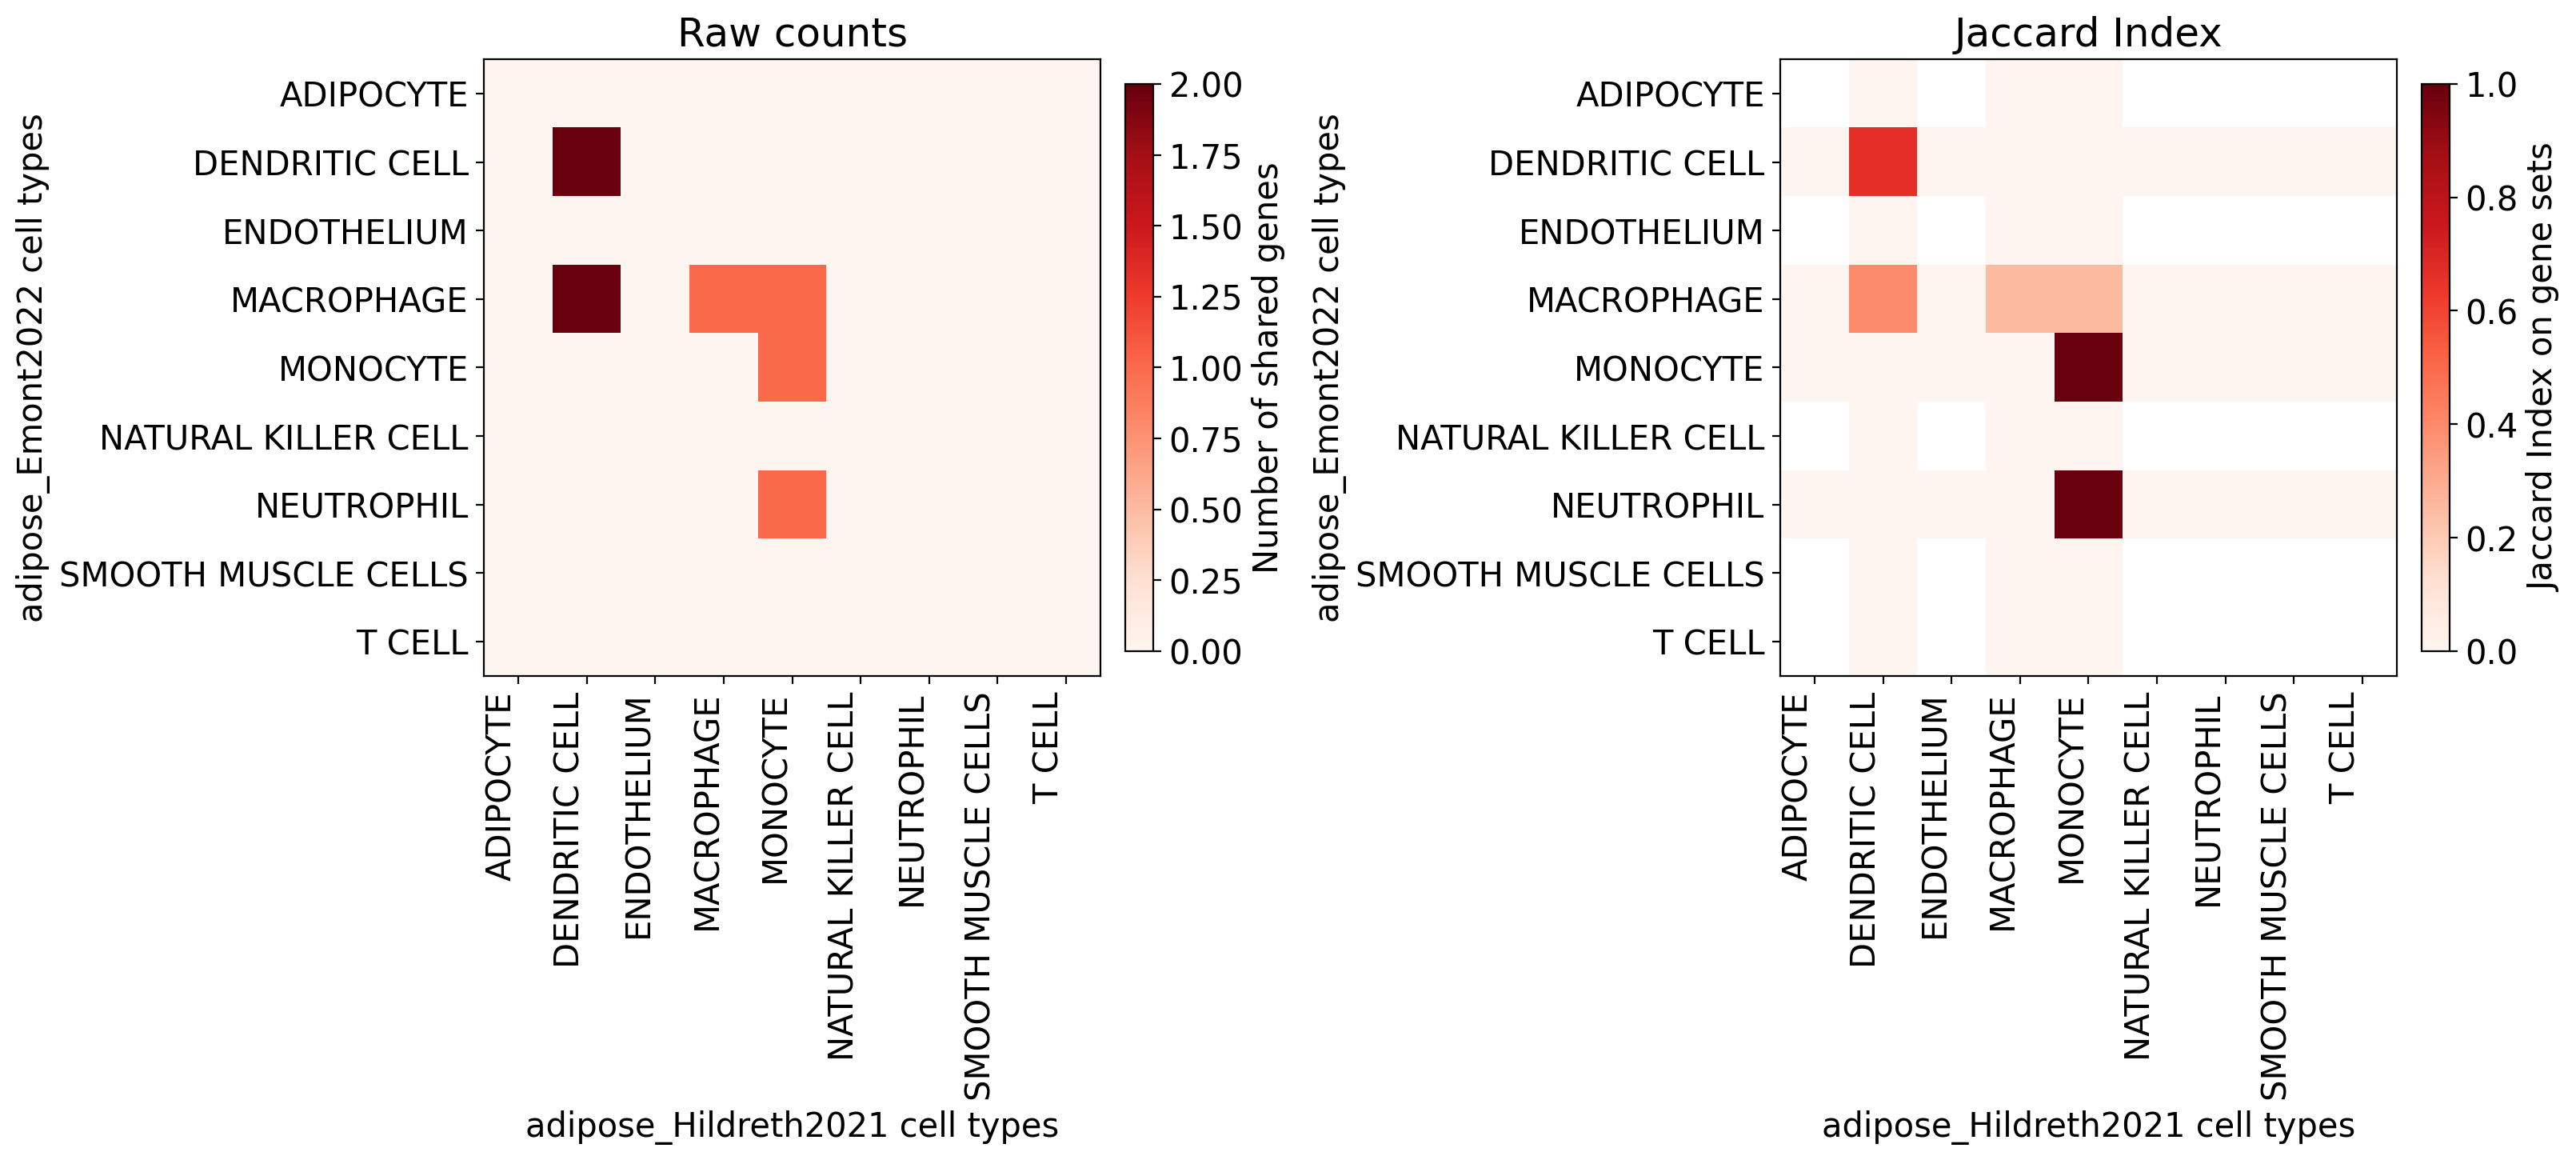

In [103]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": f"{ds2} cell types",
    "ylabel": f"{ds1} cell types",
    "xticks": np.arange(len(hmn2ct)),
    "yticks": np.arange(len(hmn1ct)),
    "xticklabels": hmn2ct,
    "yticklabels": hmn1ct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds", vmin=0, vmax=1)
ax.set(**{
    "xlabel": f"{ds2} cell types",
    "ylabel": f"{ds1} cell types",
    "xticks": np.arange(len(hmn2ct)),
    "yticks": np.arange(len(hmn1ct)),
    "xticklabels": hmn2ct,
    "yticklabels": hmn1ct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


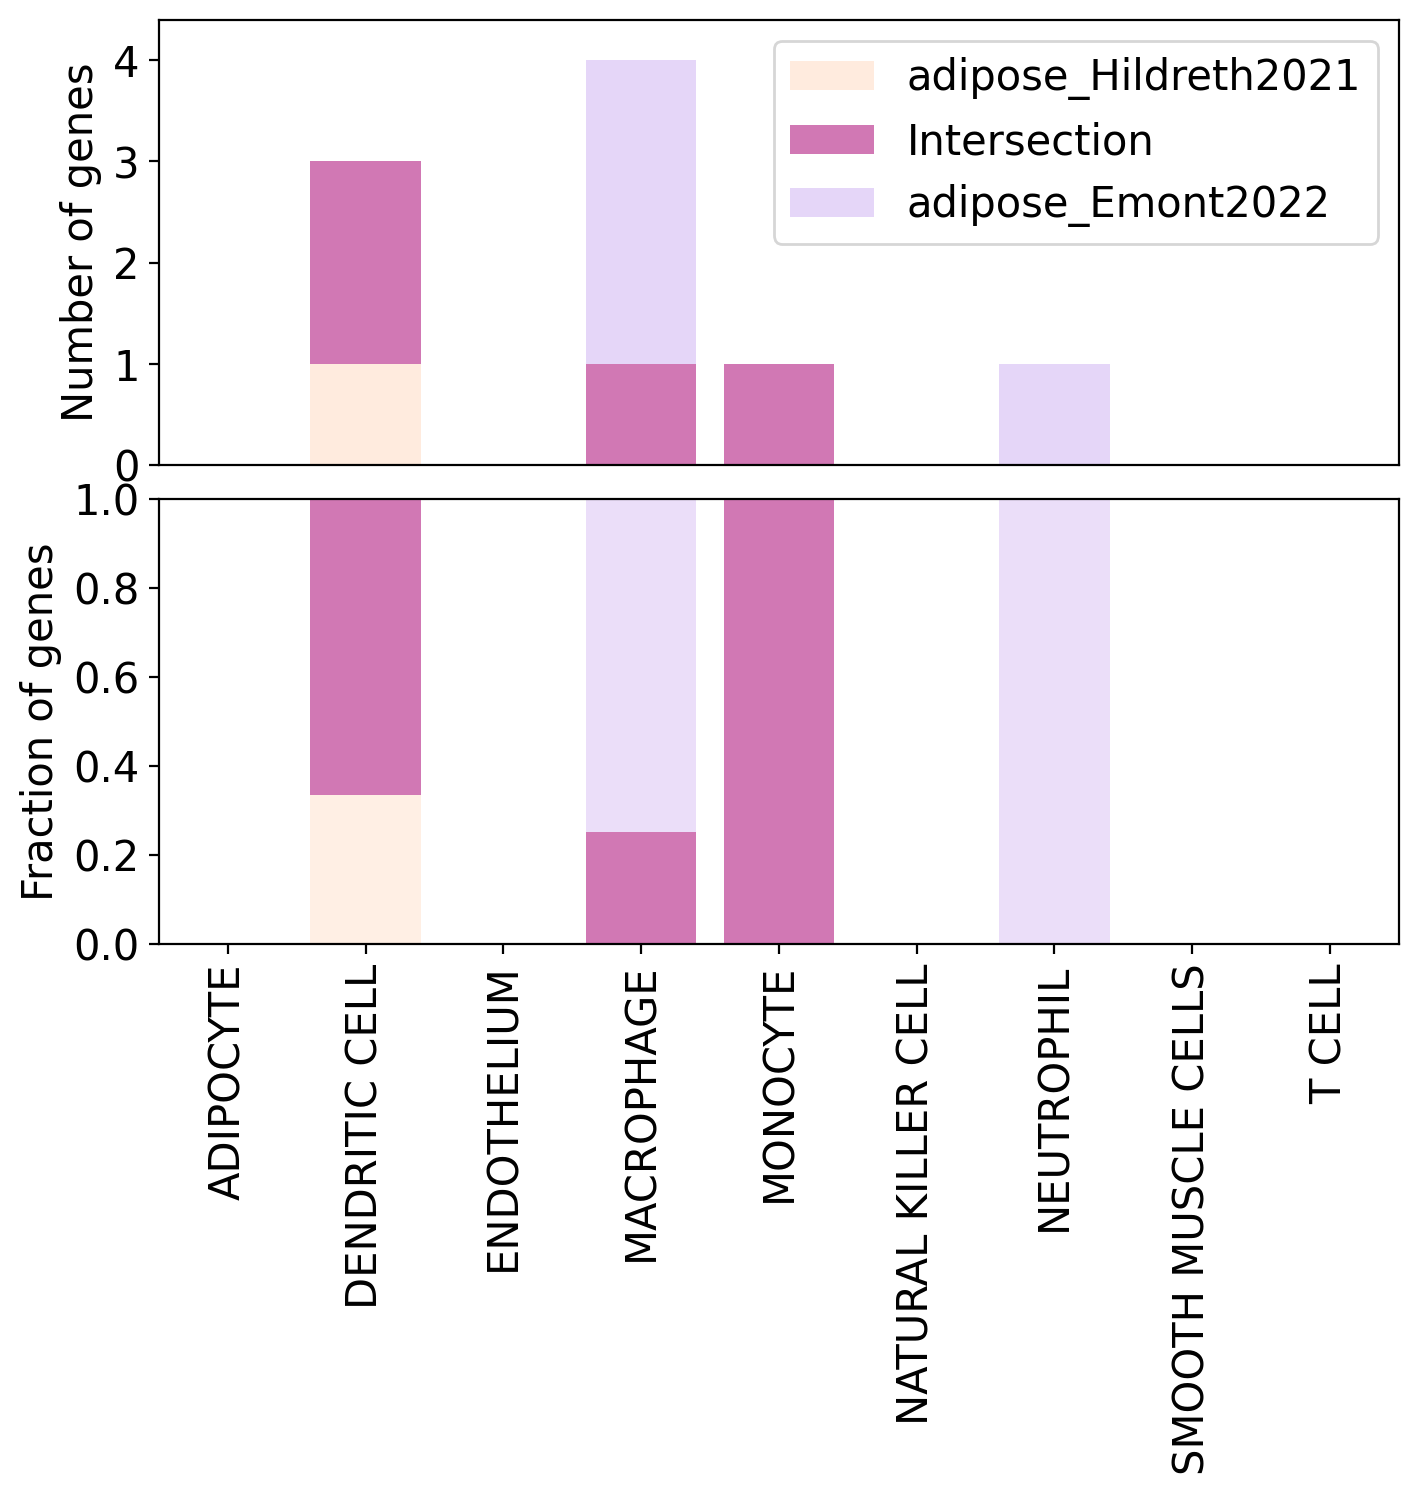

In [71]:
fig, axs = plt.subplots(figsize=(8,6), nrows=2)
fig.subplots_adjust(hspace=0.075, wspace=0.5)
ax = axs[0]
y3 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y1 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmn1ct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.25, label=f'{ds2}')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.25, label=f'{ds1}')

ax.set(
    **{
        "ylabel": "Number of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max()),
        "xlim": (-0.5, len(x)-0.5)
    }
)
ax.xaxis.set_visible(False)

# ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend()#bbox_to_anchor=(1,1))

ax = axs[1]
ax.sharex(axs[0])
y3 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y1 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmn1ct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'{ds2}')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'{ds1}')

ax.set(
    **{
        "ylabel": "Fraction of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1),
        "xlim": (-0.5, len(x)-0.5)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()
